In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import sys

sys.path.insert(0, "../../src")

import gc
import time

import numpy as np
import torch
import matplotlib.pyplot as plt 

from juart.dl.checkpoint.manager import CheckpointManager

In [2]:
directory1 = "total_trn_loss_test/model"
directory2 = "ResNet_0i_100DC_10P_1000spk_normalized/model_epoch_30"
directory3 = "oldh5_ResNet_0i_100DC_10P/model_epoch_3"
root_dir = "/home/jovyan/models"
backend = "local"
device = "cpu"

In [3]:
checkpoint_manager1 = CheckpointManager(
    directory = directory1,
    root_dir=root_dir,
    backend=backend,
)

checkpoint_manager2 = CheckpointManager(
    directory = directory2,
    root_dir=root_dir,
    backend=backend,
)

checkpoint_manager3 = CheckpointManager(
    directory = directory3,
    root_dir=root_dir,
    backend=backend,
)

In [4]:
checkpoint1 = checkpoint_manager1.load(["trn_loss"],map_location = device)
checkpoint2 = checkpoint_manager2.load(["trn_loss"],map_location = device)
checkpoint3 = checkpoint_manager3.load(["trn_loss"],map_location = device)

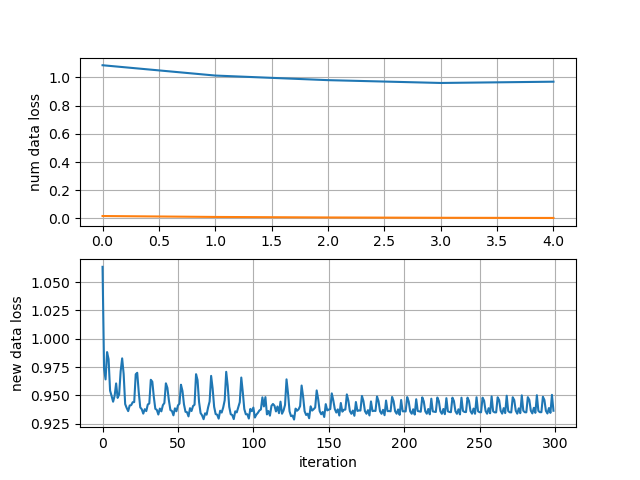

In [6]:
fig, ax = plt.subplots(2,1)

ax[0].plot(checkpoint1["trn_loss"]["loss_kspace"])
ax[0].plot(checkpoint1["trn_loss"]["loss_ispace"])
ax[1].plot(checkpoint2["trn_loss"])

for i in range(2):
    ax[i].grid(True)

ax[0].set_ylabel("num data loss")
ax[1].set_ylabel("new data loss")
ax[1].set_xlabel("iteration")

plt.show()